# Credit Card Fraud Detection

This notebook trains a machine learning model on real credit card transaction data to detect fraudulent activity. It covers data exploration, class imbalance handling, model training, and evaluation using precision, recall, and F1 score.

## 1. Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from imblearn.over_sampling import SMOTE
import seaborn as sns

## 2. Load Data

In [2]:
df = pd.read_csv('creditcard.csv')

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
fraud_percentage = df['Class'].mean() * 100
print(f"{fraud_percentage:.4f}%")

0.1727%


## 3. Exploratory Data Analysis

### Class Distribution

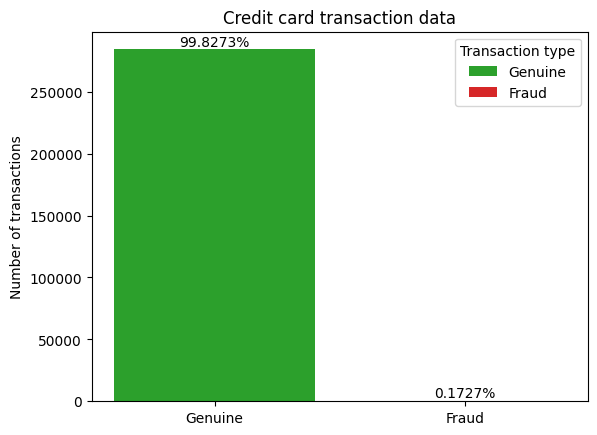

In [7]:
fig, ax = plt.subplots()

df_counts = df['Class'].value_counts()
bar1 = df_counts[0]
bar2 = df_counts[1]

fraud_percentage = df['Class'].mean() * 100
fraud_percentage_str = f"{fraud_percentage:.4f}%"
genuine_percentage_str = f"{100 - fraud_percentage:.4f}%"
percentages = [genuine_percentage_str, fraud_percentage_str]

labels = ['Genuine', 'Fraud']
counts = [bar1, bar2]

bar_labels = ['Genuine', 'Fraud']
bar_colors = ['tab:green', 'tab:red']

bar_container = ax.bar(labels, counts, label=bar_labels, color=bar_colors)

ax.set_ylabel('Number of transactions')
ax.set_title('Credit card transaction data')
ax.legend(title='Transaction type')
ax.bar_label(bar_container, percentages)

plt.show()

The dataset is heavily imbalanced. Only 0.17% of transactions are fraudulent. 
This means standard accuracy metrics are misleading and require special handling during model training.

### Average Transaction Amounts

In [8]:
average_amount_fraudulent = df[df['Class'] == 1]['Amount'].mean()
average_amount_genuine = df[df['Class'] == 0]['Amount'].mean()

print(f"Average amount spent on fraudulent transactions: {average_amount_fraudulent:.4f}")
print(f"Average amount spent on genuine transactions: {average_amount_genuine:.4f}")

Average amount spent on fraudulent transactions: 122.2113
Average amount spent on genuine transactions: 88.2910


Data analysis shows that average transactions amount for fraudulent transactions is higher than average amount for genuine transactions. This might allow lower value fraudulent transactions to slip through as they look more like a genuine transaction.

### Amount Distribution: Fraud vs Genuine

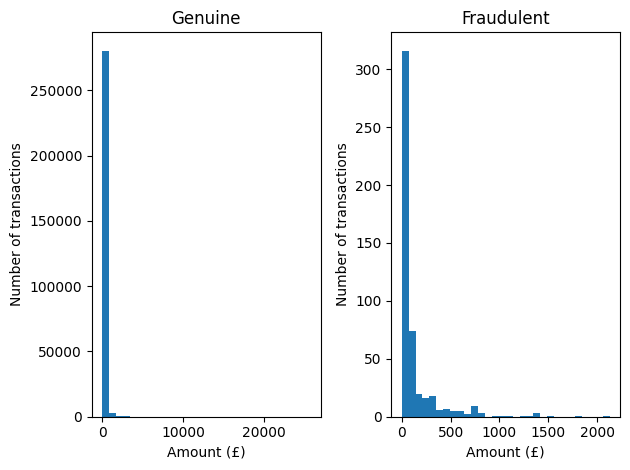

In [9]:
genuine_amounts = df[df['Class'] == 0]['Amount']
fraudulent_amounts = df[df['Class'] == 1]['Amount']

fig, axs = plt.subplots(1, 2)

axs[0].hist(genuine_amounts, bins=30)
axs[0].set_title('Genuine')
axs[0].set_xlabel("Amount (£)")
axs[0].set_ylabel("Number of transactions")
axs[1].hist(fraudulent_amounts, bins=30)
axs[1].set_title('Fraudulent')
axs[1].set_xlabel("Amount (£)")
axs[1].set_ylabel("Number of transactions")

plt.tight_layout()
plt.show()

Histograms show that genuine transactions reach a maximum amount of £25,691, while fraudulent transactions are capped at £2,125. Both distributions are right-skewed, meaning the vast majority of transactions are concentrated at low amounts. This suggests that fraudsters deliberately target lower value transactions to increase their chances of going undetected.

### Correlation Heatmap

<Axes: >

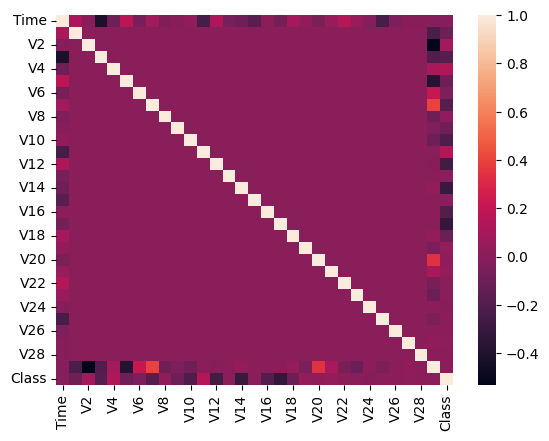

In [10]:
correlation_data = df.corr()

fig, ax = plt.subplots()

sns.heatmap(correlation_data, ax=ax)

In [11]:
df.corr()['Class'].sort_values()

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64

The heatmap and correlation values against the Class column show that the most valuable PCA features for training the model are V17, V14, V12, V10, V16, V3, V7, V18, V1, V9, V5, V2, V4 and V11. These have the strongest correlation with Class in either direction. Notably, Amount has almost no correlation with Class (0.006), which is surprising given that the histogram above shows fraudulent transactions tend to involve lower amounts on average. This suggests that Amount alone is not a reliable fraud signal and the model will rely primarily on the anonymised PCA features.

## 4. Data Preparation

### Define Features and Target (X and y)

In [12]:
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

print(X.head())
print(y.head())

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V20       V21       V22       V23  \
0  0.098698  0.363787  0.090794  ...  0.251412 -0.018307  0.277838 -0.110474   
1  0.085102 -0.255425 -0.166974  ... -0.069083 -0.225775 -0.638672  0.101288   
2  0.247676 -1.514654  0.207643  ...  0.524980  0.247998  0.771679  0.909412   
3  0.377436 -1.387024 -0.054952  ... -0.208038 -0.108300  0.005274 -0.190321   
4 -0.270533  0.817739  0.753074  ...  0.408542 -0.009431  0.798278 -0.137458   

        V24       V25       V26       V27       V28  Amount  
0  0.0

We define X as the feature matrix containing all PCA features (V1–V28) and Amount. These are the signals the model will learn from, as they directly influence whether a transaction is fraudulent or genuine. We define y as the target vector containing only the Class column (0 = genuine, 1 = fraud). Time is excluded from X as it is a transaction counter with no predictive value for fraud detection.

### Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(227845, 29)
(56962, 29)
(227845,)
(56962,)


Using train_test_split we split the dataset 80/20. 80% for training, 20% held back for testing. The model never sees the test set during training, which simulates real-world unseen data and gives us an honest evaluation of performance. The split is randomised (shuffled) before dividing, and random_state=42 fixes the random seed so the split is identical every time the code runs, ensuring reproducibility.

### Handle Class Imbalance with SMOTE

In [14]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(X_train_res.shape)
print(y_train_res.value_counts())

(454902, 29)
Class
0    227451
1    227451
Name: count, dtype: int64


We apply SMOTE (Synthetic Minority Oversampling Technique) only to the training data to address the severe class imbalance - 0.17% fraud vs 99.83% genuine. SMOTE generates synthetic fraud transactions based on existing real ones, balancing the classes from 227,845 genuine vs 394 fraud to 227,451 vs 227,451. We apply it only to the training set to ensure the test set contains only real transactions, giving us an honest evaluation of model performance on unseen data.

## 5. Model Training

In [15]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
y_pred = rf_classifier.predict(X_test)

In [17]:
classification_rep = classification_report(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)

print("\nClassification Report:\n", classification_rep)
print("\nConfusion Matrix:\n", confusion_mat)


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
 [[56853    11]
 [   15    83]]


We train a Random Forest model with 100 estimators on the SMOTE-resampled training data (X_train_res, y_train_res). The model then predicts fraud on the unseen test set (X_test) - 20% of the original dataset that was never seen during training. For fraud (Class 1): recall of 0.85 means 15% of real fraud transactions were missed, and precision of 0.88 means 12% of transactions flagged as fraud were actually genuine. For a first untuned model these are strong results, though in production recall would need to be pushed higher to minimise missed fraud.

### Confusion Matrix

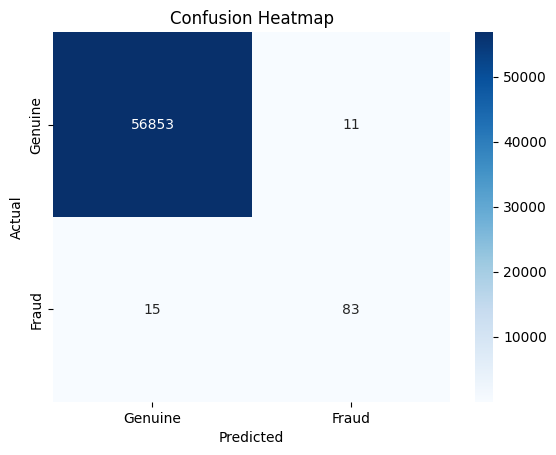

In [18]:
fig, ax = plt.subplots()

sns.heatmap(confusion_mat, ax=ax, annot=True, fmt='d', cmap='Blues')

ax.set_title('Confusion Heatmap')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticklabels(['Genuine', 'Fraud'])
ax.set_yticklabels(['Genuine', 'Fraud']);

The model correctly identified 56,853 genuine transactions (true negatives) and caught 83 fraudulent transactions (true positives).

The critical miss is 15 false negatives, real fraud the model labelled as genuine. In production this means missed fraud, direct financial loss, and damaged customer trust. This is the costlier error.

11 false positives, genuine transactions flagged as fraud, are less damaging but still create friction for customers. The model's balance here is acceptable for a first untuned version.

## Model Tuning
### Threshold Tuning

In [19]:
y_pred_proba  = rf_classifier.predict_proba(X_test)
y_scores = y_pred_proba[:, 1]

y_pred_tuned = y_scores > 0.3
classification_rep_tuned = classification_report(y_test, y_pred_tuned)

print(f"Classification report for threshold tuning 0.3:\n", classification_rep_tuned)

Classification report for threshold tuning 0.3:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.88      0.85        98

    accuracy                           1.00     56962
   macro avg       0.91      0.94      0.93     56962
weighted avg       1.00      1.00      1.00     56962



By lowering the threshold to 0.3 compared to the default 0.5 we improve recall from 0.85 to 0.88, meaning we catch more real fraudulent transactions by 3%. However precision dropped from 0.88 to 0.83, meaning we flag 5% more genuine transactions as fraud compared to the original prediction. For fraud detection this is an acceptable trade-off, as catching more real fraud reduces financial and reputational damage.

### Precision-Recall Curve

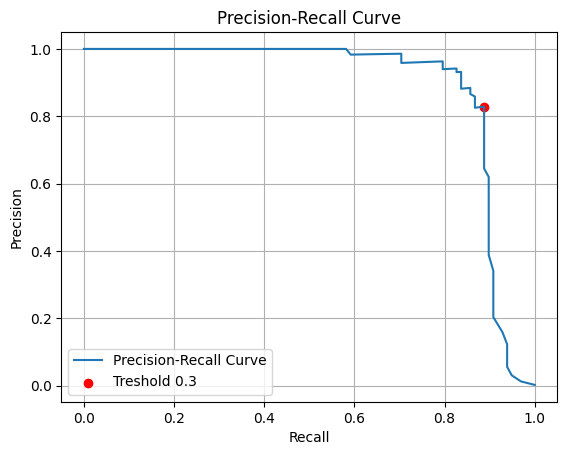

In [28]:
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure()
plt.plot(recall, precision, label = 'Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)


tuned_threshold =np.argmin(np.abs(thresholds - 0.3))
plt.scatter(recall[tuned_threshold], precision[tuned_threshold], label = f'Threshold 0.3', color = 'red')

plt.legend()
plt.show()

The Precision-Recall Curve shows the trade-off between precision and recall across every possible threshold. The red dot marks our chosen threshold of 0.3, which sits just before the point where precision drops sharply. This confirms 0.3 is a strong choice, maintaining high recall while keeping precision acceptable.